# Stage 2 Clustering

This notebook builds behavioral learner profiles from Stage 2 weekly trajectories. Unlike the predictive notebooks, clustering is unsupervised: `is_dropout_point` is not used to fit the clusters and is added only afterward for interpretation.

The goal is to describe typical temporal patterns of learner behavior, such as consistently low activity, early peaks followed by decline, sustained engagement, or stable moderate use.


## Setup


In [18]:
import os
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd()

from src.preprocess import build_stage2_dataset
from src import clustering_utils as cluster
from src import fairness_utils as fairness

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)


## Configuration

Spectral clustering builds an `n x n` similarity matrix, so memory grows quadratically with the number of trajectory windows. The notebook therefore works on a stratified subsample of sequences. Stratification preserves the dropout-point rate in the sampled data while keeping the eigendecomposition tractable.

The same subsample is reused for all methods, which makes method comparisons meaningful.


In [2]:
@dataclass(frozen=True)
class Config:
    data_dir: Path = PROJECT_ROOT / "data"
    output_dir: Path = PROJECT_ROOT / "outputs"
    random_state: int = RANDOM_STATE

    sequence_length: int = 12
    k_min: int = 2
    k_max: int = 8

    # Spectral clustering scales quadratically in memory because it builds an
    # n x n similarity matrix. Keep this capped unless you have a lot of RAM.
    sample_size: int = 7_500

    aggregated_k: int = 4
    euclidean_k: int = 4
    rbf_base_gamma: float = 1.0
    save_outputs: bool = True


CFG = Config()
CFG.output_dir.mkdir(exist_ok=True)
CFG


Config(data_dir=WindowsPath('c:/Users/loicm/Documents/EPFL/2025-2026/MA4/ML_for_BD/CS-421-Project-learnavi/data'), output_dir=WindowsPath('c:/Users/loicm/Documents/EPFL/2025-2026/MA4/ML_for_BD/CS-421-Project-learnavi/outputs'), random_state=42, sequence_length=12, k_min=2, k_max=8, sample_size=7500, aggregated_k=4, euclidean_k=4, rbf_base_gamma=1.0, save_outputs=True)

## Build Stage 2 Trajectory Tensor

The weekly Stage 2 table is converted into a tensor of 12-week behavioral sequences. Calendar variables are excluded from the clustering features so that clusters reflect learning behavior rather than mostly seasonality.

Each sequence corresponds to a trajectory window ending at a specific learner-week. The dropout-point label is kept only as metadata for post-hoc interpretation.


In [ ]:
stage2 = build_stage2_dataset(CFG.data_dir)
df_full = stage2.df_full
feature_cols = stage2.feature_cols

# Exclude calendar variables so clusters are behavioral, not mostly seasonal.
behavior_features = [c for c in feature_cols if c not in {"year", "day"}]

X_seq, y_seq, traj_df, weekly_preprocess = cluster.build_trajectory_sequences(
    df_full,
    behavior_features,
    sequence_length=CFG.sequence_length,
)

print("Full sequence tensor:", X_seq.shape)
print("Full dropout-point rate:", round(float(y_seq.mean()), 3))
print("Behavior features:", behavior_features)


Full sequence tensor: (222739, 12, 15)
Full dropout-point rate: 0.492
Behavior features: ['n_events', 'n_active_days', 'mean_hour', 'n_click_events', 'n_view_events', 'n_sessions', 'n_topics_event', 'n_transactions', 'correct_rate', 'partial_rate', 'mean_evaluation_score', 'avg_response_time', 'n_documents', 'n_topics_transaction', 'activity_score']


## Stratified Subsample

The subsample is stratified on `is_dropout_point`, but the label is still not used as a clustering feature. This keeps rare interruption windows represented in the analysis without letting the algorithm directly optimize for the outcome.

All clustering methods below use this exact same sample.


In [ ]:
X_seq_s, y_seq_s, traj_df_s = cluster.stratified_subsample(
    X_seq,
    y_seq,
    traj_df,
    sample_size=CFG.sample_size,
    random_state=CFG.random_state,
)

print("Subsample tensor:", X_seq_s.shape)
print("Subsample dropout-point rate:", round(float(y_seq_s.mean()), 3))
traj_df_s.head()


Subsample tensor: (7500, 12, 15)
Subsample dropout-point rate: 0.492


,user_id,end_week,row_index,is_dropout_point
0,387604,46,46,0
1,387605,26,114,0
2,387608,68,231,0
3,387615,50,294,0
4,387615,60,304,1


## Strategy A: Spectral On Aggregated Trajectories

The first strategy averages each behavioral feature across the 12-week window before computing an RBF similarity matrix. This removes temporal order and gives a compact baseline profile of overall engagement level.

Because it collapses time, this method is useful for asking what is lost when trajectory shape is ignored.


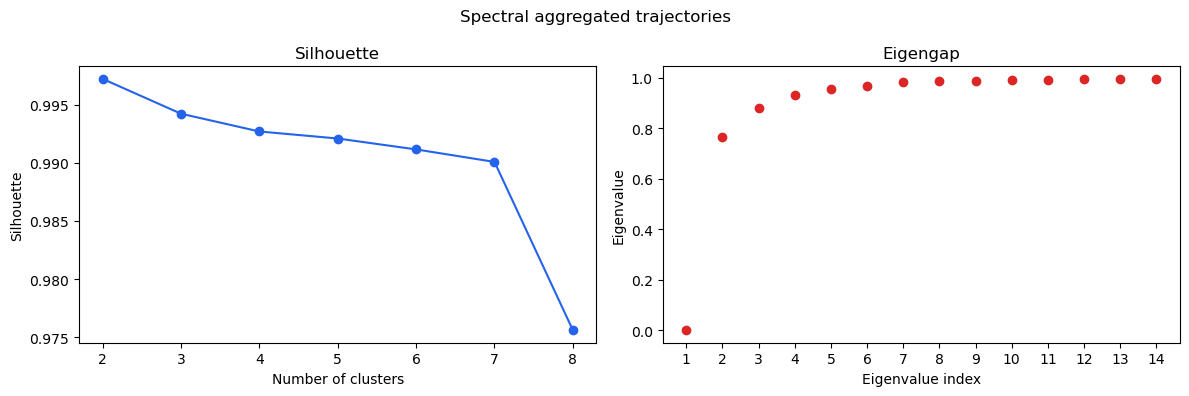

,spectral_agg,n_sequences,n_users,dropout_point_rate,share_sequences
0,0,7489,4397,0.492723,0.998533
1,1,3,3,0.333333,0.000400
2,2,2,2,1.000000,0.000267
3,3,6,6,0.000000,0.000800


In [ ]:
X_agg = X_seq_s.mean(axis=1)
W_agg = cluster.adjacency_from_similarity(cluster.rbf_similarity(X_agg, CFG.rbf_base_gamma))

k_values = range(CFG.k_min, CFG.k_max + 1)
labels_agg_by_k, diagnostics_agg, eigenvals_agg = cluster.spectral_k_diagnostics(
    W_agg,
    k_values,
    random_state=CFG.random_state,
)
cluster.plot_k_diagnostics(
    diagnostics_agg,
    eigenvals_agg,
    title="Spectral aggregated trajectories",
)

traj_df_s["spectral_agg"] = labels_agg_by_k[CFG.aggregated_k]
cluster.trajectory_overview(traj_df_s, "spectral_agg")


## Strategy B: Spectral On L2-Normalized Flattened Trajectories

The second strategy keeps the 12-week shape. Each sequence is normalized feature-wise and flattened before computing RBF similarity, so the clustering emphasizes trajectory patterns rather than absolute activity level alone.

This method is better suited for distinguishing learners who decline, recover, or remain stable over time, even if their overall activity volume is similar.


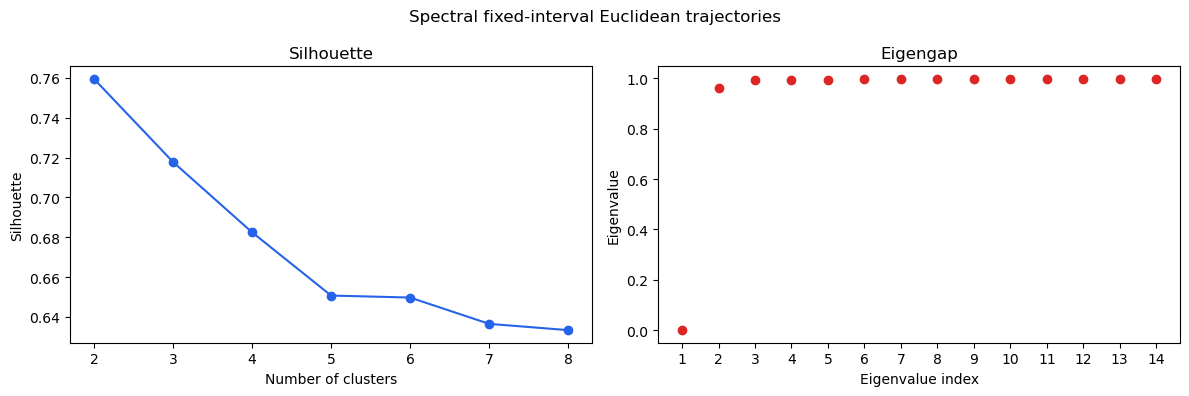

,spectral_eucl,n_sequences,n_users,dropout_point_rate,share_sequences
0,0,620,600,0.480645,0.082667
1,1,4519,2997,0.524231,0.602533
2,2,1380,1165,0.426812,0.184000
3,3,981,860,0.445464,0.130800


In [ ]:
X_seq_norm = cluster.per_sequence_l2_normalize(X_seq_s)
X_flat_norm = X_seq_norm.reshape(X_seq_norm.shape[0], -1)
W_eucl = cluster.adjacency_from_similarity(cluster.rbf_similarity(X_flat_norm, CFG.rbf_base_gamma))

labels_eucl_by_k, diagnostics_eucl, eigenvals_eucl = cluster.spectral_k_diagnostics(
    W_eucl,
    k_values,
    random_state=CFG.random_state,
)
cluster.plot_k_diagnostics(
    diagnostics_eucl,
    eigenvals_eucl,
    title="Spectral fixed-interval Euclidean trajectories",
)

traj_df_s["spectral_eucl"] = labels_eucl_by_k[CFG.euclidean_k]
cluster.trajectory_overview(traj_df_s, "spectral_eucl")


## Matched K-Means Baselines

K-Means baselines are fitted on the same sampled sequences. The raw flattened baseline tests a standard Euclidean clustering of sequence vectors, while the normalized baseline uses the same representation as the spectral trajectory method.

This separates two questions: whether the representation matters, and whether spectral clustering adds value beyond K-Means on that representation.


In [ ]:
X_flat_raw = X_seq_s.reshape(X_seq_s.shape[0], -1)

traj_df_s["kmeans_flat"], kmeans_flat = cluster.run_kmeans_clustering(
    X_flat_raw,
    n_clusters=CFG.euclidean_k,
    random_state=CFG.random_state,
)
traj_df_s["kmeans_eucl"], kmeans_eucl = cluster.run_kmeans_clustering(
    X_flat_norm,
    n_clusters=CFG.euclidean_k,
    random_state=CFG.random_state,
)

pd.concat(
    {
        "kmeans_flat": cluster.trajectory_overview(traj_df_s, "kmeans_flat"),
        "kmeans_eucl": cluster.trajectory_overview(traj_df_s, "kmeans_eucl"),
    },
    names=["method", "row"],
)


kmeans_flat  n_sequences  n_users  dropout_point_rate  \
method      row                                                          
kmeans_flat 0            0.0         6421     3887            0.511291   
            1            1.0          548      518            0.458029   
            2            2.0          461      399            0.284165   
            3            3.0           70       66            0.400000   
kmeans_eucl 0            NaN         4531     2984            0.525712   
            1            NaN         1036      899            0.410232   
            2            NaN          598      578            0.484950   
            3            NaN         1335     1137            0.446442   

                 share_sequences  kmeans_eucl  
method      row                                
kmeans_flat 0           0.856133          NaN  
            1           0.073067          NaN  
            2           0.061467          NaN  
            3           0.009333          NaN  
kmeans_eucl 0           0.604133          0.0  
            1           0.138133          1.0  
            2           0.079733          2.0  
            3           0.178000          3.0

## Method Comparison

Cluster summaries report size, number of unique users, and dropout-point rate for each method. The adjusted Rand index compares whether two methods assign similar partitions to the same trajectory windows.

The comparison should be read as a robustness check, not as a search for one universally correct clustering.


In [ ]:
methods = ["spectral_agg", "spectral_eucl", "kmeans_flat", "kmeans_eucl"]

summary_tables = []
for method in methods:
    table = cluster.trajectory_overview(traj_df_s, method)
    table.insert(0, "method", method)
    summary_tables.append(table.rename(columns={method: "cluster"}))

cluster_summary = pd.concat(summary_tables, ignore_index=True)
method_comparison = cluster.method_adjusted_rand_table(traj_df_s, methods)
cluster_summary, method_comparison


(           method  cluster  n_sequences  n_users  dropout_point_rate  \
 0    spectral_agg        0         7489     4397            0.492723   
 1    spectral_agg        1            3        3            0.333333   
 2    spectral_agg        2            2        2            1.000000   
 3    spectral_agg        3            6        6            0.000000   
 4   spectral_eucl        0          620      600            0.480645   
 5   spectral_eucl        1         4519     2997            0.524231   
 6   spectral_eucl        2         1380     1165            0.426812   
 7   spectral_eucl        3          981      860            0.445464   
 8     kmeans_flat        0         6421     3887            0.511291   
 9     kmeans_flat        1          548      518            0.458029   
 10    kmeans_flat        2          461      399            0.284165   
 11    kmeans_flat        3           70       66            0.400000   
 12    kmeans_eucl        0         4531     2984  

## Trajectory Profiles

The profile plots aggregate features into interpretable behavioral dimensions: activity, regularity, performance, and breadth. Plotting these dimensions over time makes the clusters easier to describe than looking at hundreds of raw weekly feature values.

The outcome label is still used only after clustering, to describe whether certain trajectory profiles are associated with higher interruption risk.


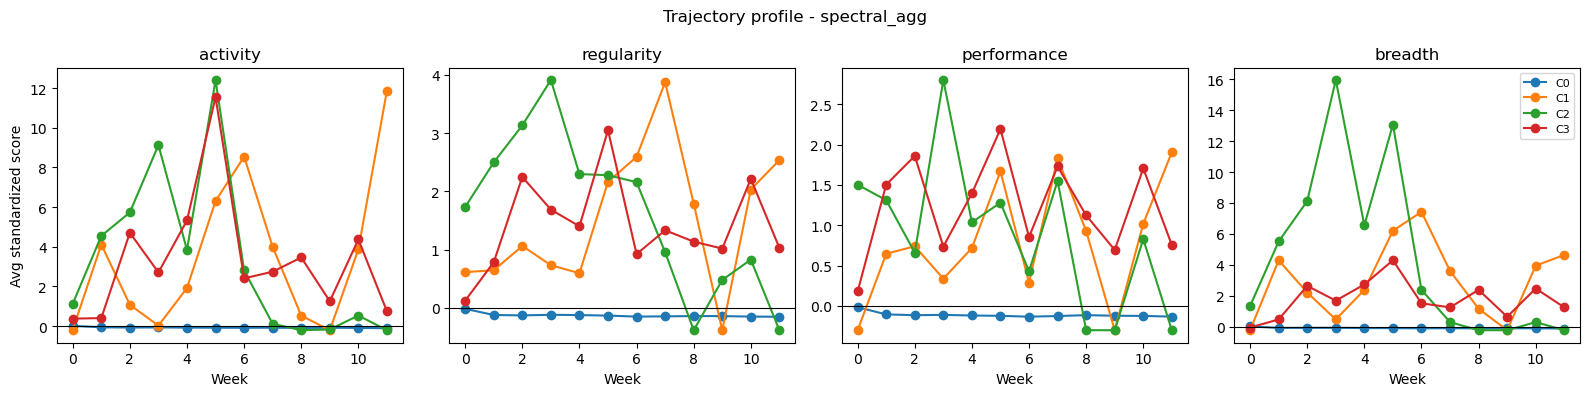

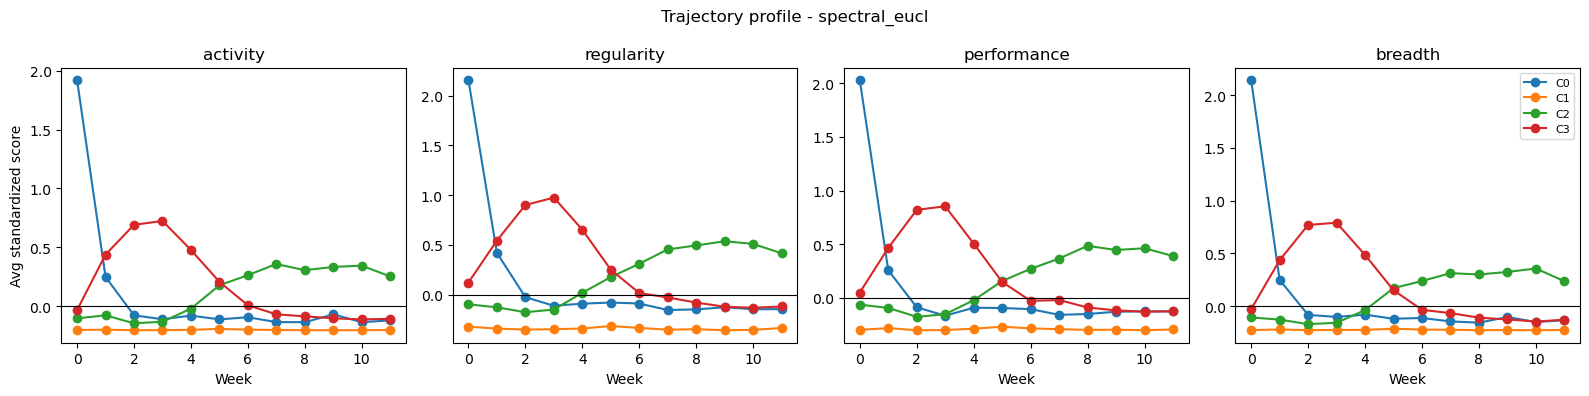

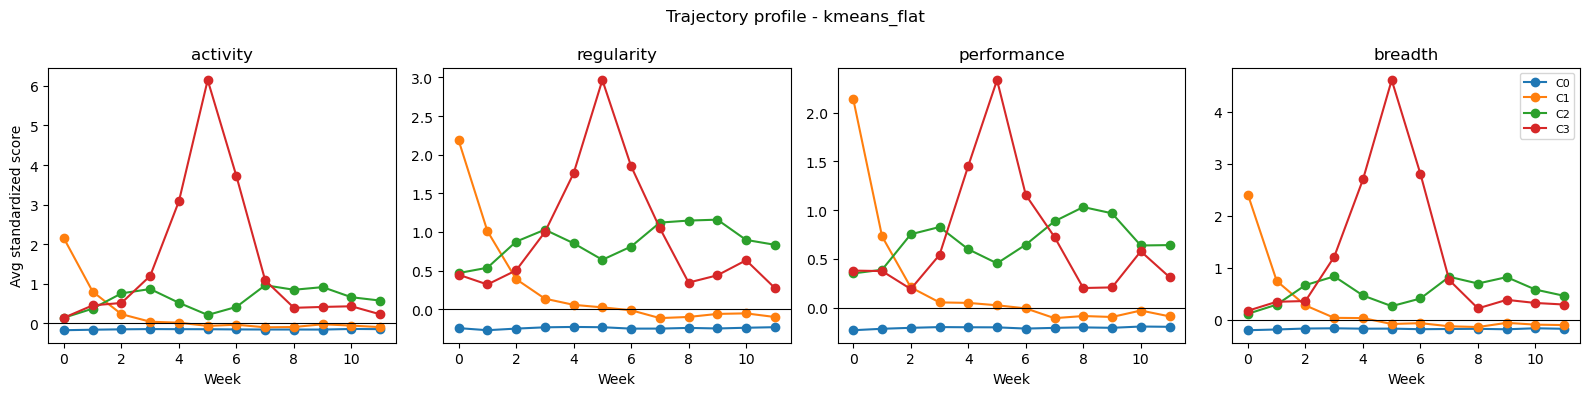

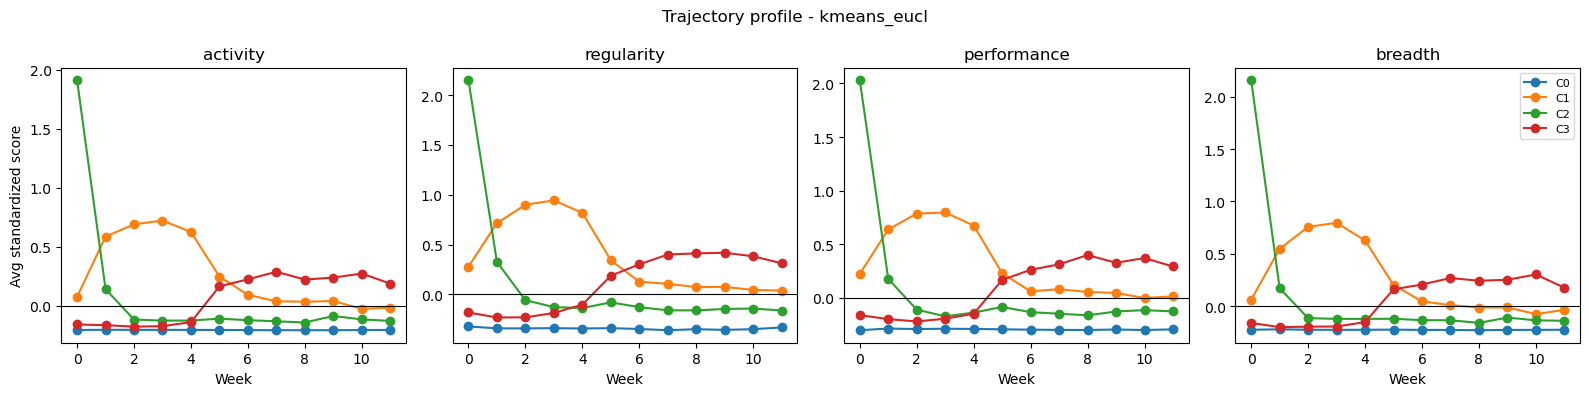

In [ ]:
trajectory_groups = {
    "activity": [
        "n_events",
        "n_click_events",
        "n_view_events",
        "n_transactions",
        "n_documents",
        "n_sessions",
        "activity_score",
    ],
    "regularity": ["n_active_days", "mean_hour"],
    "performance": ["correct_rate", "partial_rate", "mean_evaluation_score"],
    "breadth": ["n_topics_event", "n_topics_transaction"],
}

for method in methods:
    cluster.plot_trajectory_profiles(
        X_seq_s,
        traj_df_s[method].to_numpy(),
        behavior_features,
        trajectory_groups,
        title=f"Trajectory profile - {method}",
    )


## Demographic Outcome Diagnostics

This section merges the Stage 2 trajectory clusters with Stage 1 demographic fields and reports dropout-point rates within each cluster-group combination. The purpose is exploratory fairness diagnostics: we want to know whether the behavioral clusters have different outcome patterns for gender, education level, or school type.

Counts are filtered with `MIN_GROUP_SIZE` to avoid over-interpreting tiny cells. Because the clustering uses trajectory windows, not unique learners, the tables report both row support and unique-user support.


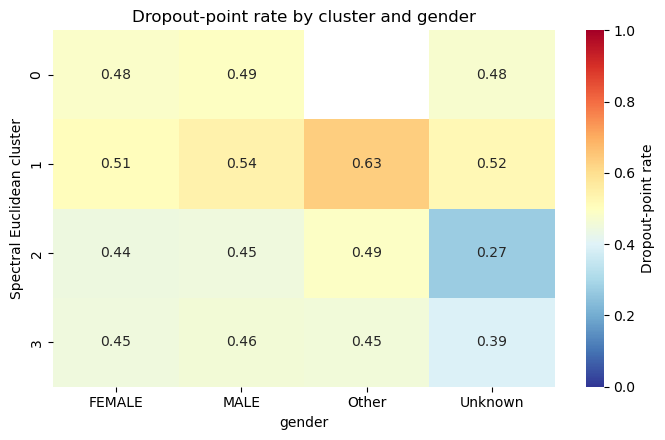

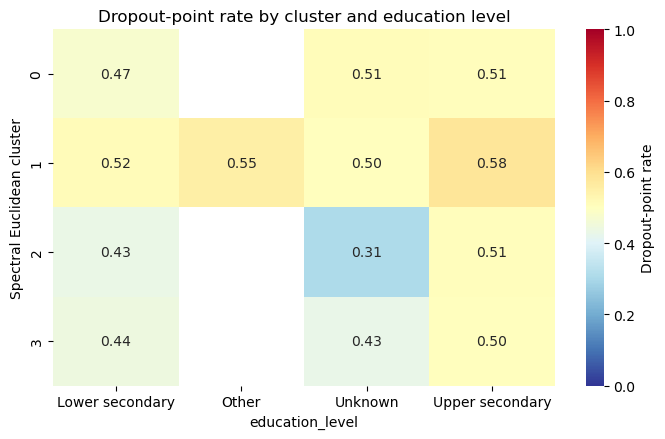

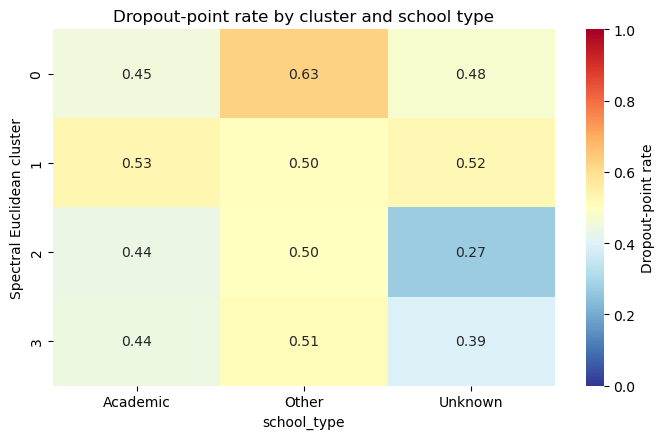

In [20]:
MIN_GROUP_SIZE = 30
CLUSTER_COL = "spectral_eucl"
OUTCOME_COL = "is_dropout_point"

df_stage1 = pd.read_csv(CFG.data_dir / "stage1.csv.gz")

demographics = fairness.extract_stage1_demographics(df_stage1)

analysis_df = traj_df_s.merge(demographics, on="user_id", how="left")
analysis_df["gender"] = analysis_df["gender"].fillna("Unknown")
analysis_df["education_level"] = analysis_df["education_level"].fillna("Unknown")
analysis_df["school_type"] = analysis_df["school_type"].fillna("Unknown")

gender_outcome = fairness.outcome_by_cluster_and_group(
    analysis_df,
    "gender",
    min_n=MIN_GROUP_SIZE,
    cluster_col=CLUSTER_COL,
    outcome_col=OUTCOME_COL,
)

education_outcome = fairness.outcome_by_cluster_and_group(
    analysis_df,
    "education_level",
    min_n=MIN_GROUP_SIZE,
    cluster_col=CLUSTER_COL,
    outcome_col=OUTCOME_COL,
)

school_outcome = fairness.outcome_by_cluster_and_group(
    analysis_df,
    "school_type",
    min_n=MIN_GROUP_SIZE,
    cluster_col=CLUSTER_COL,
    outcome_col=OUTCOME_COL,
)

gender_pivot = fairness.plot_outcome_heatmap(
    gender_outcome,
    "gender",
    "Dropout-point rate by cluster and gender",
    cluster_col=CLUSTER_COL,
)

education_pivot = fairness.plot_outcome_heatmap(
    education_outcome,
    "education_level",
    "Dropout-point rate by cluster and education level",
    cluster_col=CLUSTER_COL,
)

school_pivot = fairness.plot_outcome_heatmap(
    school_outcome,
    "school_type",
    "Dropout-point rate by cluster and school type",
    cluster_col=CLUSTER_COL,
)


## Save Outputs

The exported files contain cluster assignments, summaries, method-comparison diagnostics, and outcome-by-group tables. Large similarity matrices are not saved because they are expensive and can be rebuilt if needed from the same configuration.


In [16]:
if CFG.save_outputs:
    assignment_cols = ["user_id", "end_week", "is_dropout_point", *methods]
    assignments = traj_df_s[assignment_cols].copy()
    assignments.to_csv(CFG.output_dir / "stage2_spectral_assignments.csv", index=False)
    cluster_summary.to_csv(CFG.output_dir / "stage2_cluster_summary.csv", index=False)
    method_comparison.to_csv(CFG.output_dir / "stage2_cluster_method_comparison.csv", index=False)
    diagnostics_agg.to_csv(CFG.output_dir / "stage2_spectral_agg_diagnostics.csv", index=False)
    diagnostics_eucl.to_csv(CFG.output_dir / "stage2_spectral_eucl_diagnostics.csv", index=False)
    gender_outcome.to_csv(CFG.output_dir / "stage2_cluster_outcome_by_gender.csv", index=False)
    education_outcome.to_csv(CFG.output_dir / "stage2_cluster_outcome_by_education.csv", index=False)
    school_outcome.to_csv(CFG.output_dir / "stage2_cluster_outcome_by_school_type.csv", index=False)

    print("saved:")
    print(CFG.output_dir / "stage2_spectral_assignments.csv", assignments.shape)
    print(CFG.output_dir / "stage2_cluster_summary.csv", cluster_summary.shape)
    print(CFG.output_dir / "stage2_cluster_method_comparison.csv", method_comparison.shape)
    print(CFG.output_dir / "stage2_spectral_agg_diagnostics.csv", diagnostics_agg.shape)
    print(CFG.output_dir / "stage2_spectral_eucl_diagnostics.csv", diagnostics_eucl.shape)
    print(CFG.output_dir / "stage2_cluster_outcome_by_gender.csv", gender_outcome.shape)
    print(CFG.output_dir / "stage2_cluster_outcome_by_education.csv", education_outcome.shape)
    print(CFG.output_dir / "stage2_cluster_outcome_by_school_type.csv", school_outcome.shape)

else:
    print("saving disabled")


saved:
c:\Users\loicm\Documents\EPFL\2025-2026\MA4\ML_for_BD\CS-421-Project-learnavi\outputs\stage2_spectral_assignments.csv (7500, 7)
c:\Users\loicm\Documents\EPFL\2025-2026\MA4\ML_for_BD\CS-421-Project-learnavi\outputs\stage2_cluster_summary.csv (16, 6)
c:\Users\loicm\Documents\EPFL\2025-2026\MA4\ML_for_BD\CS-421-Project-learnavi\outputs\stage2_cluster_method_comparison.csv (6, 3)
c:\Users\loicm\Documents\EPFL\2025-2026\MA4\ML_for_BD\CS-421-Project-learnavi\outputs\stage2_spectral_agg_diagnostics.csv (7, 2)
c:\Users\loicm\Documents\EPFL\2025-2026\MA4\ML_for_BD\CS-421-Project-learnavi\outputs\stage2_spectral_eucl_diagnostics.csv (7, 2)
c:\Users\loicm\Documents\EPFL\2025-2026\MA4\ML_for_BD\CS-421-Project-learnavi\outputs\stage2_cluster_outcome_by_gender.csv (15, 9)
c:\Users\loicm\Documents\EPFL\2025-2026\MA4\ML_for_BD\CS-421-Project-learnavi\outputs\stage2_cluster_outcome_by_education.csv (13, 9)
c:\Users\loicm\Documents\EPFL\2025-2026\MA4\ML_for_BD\CS-421-Project-learnavi\outputs\stag